<a href="https://colab.research.google.com/github/Sisi198/EEG-Study/blob/main/2025.07.26EEGLABdataprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install mne python-picard

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("MNE version:", mne.__version__)
print("All libraries loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 37.5 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


MNE version: 1.12.1
All libraries loaded!


In [ ]:
# Install AWS CLI and download sub-001 data
!pip install awscli -q

!aws s3 sync --no-sign-request \
  s3://openneuro.org/ds006648/sub-001 \
  /content/ds006648/sub-001

print("Download complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 7.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://openneuro.org/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.json to ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.json
download: s3://openneuro.org/ds006648/sub-001/eeg/sub-001_task-readpoetry_channels.tsv to ds006648/sub-001/eeg/sub-001_task-readpoetry_channels.tsv
download: s3://openneuro.org/ds006648/sub-001/eeg/sub-001_task-readpoetry_events.tsv to ds006648/sub-001/eeg/sub-001_task-readpo

In [ ]:
# Load sub-001 EEG data
raw = mne.io.read_raw_eeglab(
    '/content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set',
    preload=True
)

print("Data loaded!")
print(f"Duration: {raw.times[-1]:.1f} seconds")
print(f"Channels: {len(raw.ch_names)}")
print(f"Sampling rate: {raw.info['sfreq']} Hz")

NameError: name 'mne' is not defined

In [ ]:
# Install required libraries
!pip install mne python-picard

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("MNE version:", mne.__version__)
print("All libraries loaded!")

MNE version: 1.12.1
All libraries loaded!


In [ ]:
# Install AWS CLI and download sub-001 data
!pip install awscli -q

!aws s3 sync --no-sign-request \
  s3://openneuro.org/ds006648/sub-001 \
  /content/ds006648/sub-001

print("Download complete!")

Download complete!


In [ ]:
# Load sub-001 EEG data
raw = mne.io.read_raw_eeglab(
    '/content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set',
    preload=True
)

print("Data loaded!")
print(f"Duration: {raw.times[-1]:.1f} seconds")
print(f"Channels: {len(raw.ch_names)}")
print(f"Sampling rate: {raw.info['sfreq']} Hz")

Data loaded!
Duration: 6422.0 seconds
Channels: 70
Sampling rate: 512.0 Hz


/tmp/ipykernel_5148/3309642399.py:2: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(


In [ ]:
# Step 1. Drop EXG channels
raw.drop_channels(['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8'])
print(f"Channels after dropping EXG: {len(raw.ch_names)}")

# Step 2. Set standard montage
montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='warn')
print("Montage set!")

# Step 3. Bandpass filter (1-40 Hz)
raw.filter(l_freq=1.0, h_freq=40.0)
print("Filtering done!")

# Step 4. Re-reference to average
raw.set_eeg_reference('average', projection=False)
print("Re-referencing done!")

Channels after dropping EXG: 64
Montage set!
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (3.303 s)

Filtering done!
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Re-referencing done!


In [ ]:
# Install AWS CLI and download sub-001 data
!pip install awscli -q

!aws s3 sync --no-sign-request \
  s3://openneuro.org/ds006648/sub-001 \
  /content/ds006648/sub-001

print("Download complete!")

Download complete!


In [ ]:
# Load sub-001 EEG data
raw = mne.io.read_raw_eeglab(
    '/content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set',
    preload=True
)

print("Data loaded!")
print(f"Duration: {raw.times[-1]:.1f} seconds")
print(f"Channels: {len(raw.ch_names)}")
print(f"Sampling rate: {raw.info['sfreq']} Hz")

NameError: name 'mne' is not defined

In [ ]:
# Install required libraries
!pip install mne python-picard

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("MNE version:", mne.__version__)
print("All libraries loaded!")

MNE version: 1.12.1
All libraries loaded!


In [ ]:
# Install AWS CLI and download sub-001 data
!pip install awscli -q

!aws s3 sync --no-sign-request \
  s3://openneuro.org/ds006648/sub-001 \
  /content/ds006648/sub-001

print("Download complete!")

Download complete!


In [ ]:
# Load sub-001 EEG data
raw = mne.io.read_raw_eeglab(
    '/content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set',
    preload=True
)

print("Data loaded!")
print(f"Duration: {raw.times[-1]:.1f} seconds")
print(f"Channels: {len(raw.ch_names)}")
print(f"Sampling rate: {raw.info['sfreq']} Hz")

Data loaded!
Duration: 6422.0 seconds
Channels: 70
Sampling rate: 512.0 Hz


/tmp/ipykernel_6910/3309642399.py:2: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(


In [ ]:
# Step 1. Drop EXG channels
raw.drop_channels(['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8'])
print(f"Channels after dropping EXG: {len(raw.ch_names)}")

# Step 2. Set standard montage
montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='warn')
print("Montage set!")

# Step 3. Bandpass filter (1-40 Hz)
raw.filter(l_freq=1.0, h_freq=40.0)
print("Filtering done!")

# Step 4. Re-reference to average
raw.set_eeg_reference('average', projection=False)
print("Re-referencing done!")

Channels after dropping EXG: 64
Montage set!
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (3.303 s)

Filtering done!
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Re-referencing done!


In [ ]:
# Step 5. ICA
from mne.preprocessing import ICA

ica = ICA(n_components=63, method='picard', random_state=42)
ica.fit(raw)

print("ICA done!")
print(ica)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 63 components


In [ ]:
# Install AWS CLI and download sub-001 data
!pip install awscli -q

!aws s3 sync --no-sign-request \
  s3://openneuro.org/ds006648/sub-001 \
  /content/ds006648/sub-001

print("Download complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://openneuro.org/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.json to ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.json
download: s3://openneuro.org/ds006648/sub-001/eeg/sub-001_task-readpoetry_channels.tsv to ds006648/sub-001/eeg/sub-001_task-readpoetry_channels.tsv
download: s3://openneuro.org/ds006648/sub-001/eeg/sub-001_task-readpoetry_events.tsv to ds006648/sub-001/eeg/sub-001_task-readpo

In [ ]:
# Load sub-001 EEG data
raw = mne.io.read_raw_eeglab(
    '/content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set',
    preload=True
)

print("Data loaded!")
print(f"Duration: {raw.times[-1]:.1f} seconds")
print(f"Channels: {len(raw.ch_names)}")
print(f"Sampling rate: {raw.info['sfreq']} Hz")

NameError: name 'mne' is not defined

In [ ]:
!pip install mne python-picard -q

import mne
import numpy as np
import pandas as pd
from mne.preprocessing import ICA

print("MNE version:", mne.__version__)
print("All libraries loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 58.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
MNE version: 1.12.1
All libraries loaded!


In [ ]:
!aws s3 sync --no-sign-request \
  s3://openneuro.org/ds006648/sub-001 \
  /content/ds006648/sub-001 -q

print("Download complete!")


Unknown options: -q
Download complete!


In [ ]:
raw = mne.io.read_raw_eeglab(
    '/content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set',
    preload=False
)

print(f"Duration: {raw.times[-1]:.1f} seconds")
print(f"Channels: {len(raw.ch_names)}")

Reading /content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set
Duration: 6422.0 seconds
Channels: 70


/tmp/ipykernel_1271/401790960.py:1: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(


In [ ]:

raw.drop_channels(['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8'])


montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='warn')


raw.load_data()
raw.filter(l_freq=1.0, h_freq=40.0)

# Re-referencing
raw.set_eeg_reference('average', projection=False)

print("Preprocessing done!")

Reading 0 ... 3288063  =      0.000 ...  6421.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (3.303 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Preprocessing done!


In [ ]:

raw_short = raw.copy().crop(tmax=3000)


ica = ICA(n_components=63, method='picard', random_state=42)
ica.fit(raw_short)

print("ICA fitting done!")
print(ica)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 63 components
Fitting ICA took 1187.7s.
ICA fitting done!
<ICA | raw data decomposition, method: picard (fit in 134 iterations on 1536001 samples), 63 ICA components (64 PCA components available), channel types: eeg, no sources marked for exclusion>


In [ ]:
ica.save('sub-001-ica.fif', overwrite=True)
raw.save('sub-001-preprocessed-raw.fif', overwrite=True)
print("Saved!")

Writing ICA solution to /content/sub-001-ica.fif...
Writing /content/sub-001-preprocessed-raw.fif
Closing /content/sub-001-preprocessed-raw.fif
[done]
Saved!


In [ ]:
!pip install mne-icalabel -q

from mne_icalabel import label_components

ic_labels = label_components(raw, ica, method='iclabel')

print("Labels:", ic_labels['labels'])

NameError: name 'raw' is not defined

In [1]:
!pip install mne python-picard mne-icalabel -q

import mne
import numpy as np
import pandas as pd
from mne.preprocessing import ICA
from mne_icalabel import label_components

ica = ICA.load('sub-001-ica.fif')
raw = mne.io.read_raw_fif('sub-001-preprocessed-raw.fif', preload=True)

print("Files loaded!")
print(ica)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 16.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


AttributeError: type object 'ICA' has no attribute 'load'

In [2]:
ica = mne.preprocessing.read_ica('sub-001-ica.fif')
raw = mne.io.read_raw_fif('sub-001-preprocessed-raw.fif', preload=True)

print("Files loaded!")
print(ica)

FileNotFoundError: File does not exist: "/content/sub-001-ica.fif"

In [3]:
import os
print(os.listdir('/content/'))

['.config', 'sample_data']


In [6]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted!")

Mounted at /content/drive
Google Drive mounted!


In [7]:
import mne
import numpy as np
from mne.preprocessing import ICA


save_path = '/content/drive/MyDrive/EEG_Study/'
import os
os.makedirs(save_path, exist_ok=True)


os.system('aws s3 sync --no-sign-request s3://openneuro.org/ds006648/sub-001 /content/ds006648/sub-001')


raw = mne.io.read_raw_eeglab(
    '/content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set',
    preload=False
)


raw.drop_channels(['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8'])
montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='warn')
raw.load_data()
raw.filter(l_freq=1.0, h_freq=40.0)
raw.set_eeg_reference('average', projection=False)
print("Preprocessing done!")


raw_short = raw.copy().crop(tmax=3000)
ica = ICA(n_components=63, method='picard', random_state=42)
ica.fit(raw_short)
print("ICA done!")


ica.save(save_path + 'sub-001-ica.fif', overwrite=True)
raw.save(save_path + 'sub-001-preprocessed-raw.fif', overwrite=True)
print("Saved to Google Drive!")

FileNotFoundError: input_fname does not exist: "/content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set"

In [8]:
!pip install awscli -q
!aws s3 sync --no-sign-request s3://openneuro.org/ds006648/sub-001 /content/ds006648/sub-001
print("Download done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 8.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://openneuro.org/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.json to ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.json
download: s3://openneuro.org/ds006648/sub-001/eeg/sub-001_task-readpoetry_channels.tsv to ds006648/sub-001/eeg/sub-001_task-readpoetry_channels.tsv
download: s3://openneuro.org/ds006648/sub-001/eeg/sub-001_task-readpoetry_events.tsv to ds006648/sub-001/eeg/sub-001_task-readpo

In [9]:
import mne
import numpy as np
import os
from mne.preprocessing import ICA

save_path = '/content/drive/MyDrive/EEG_Study/'
os.makedirs(save_path, exist_ok=True)


raw = mne.io.read_raw_eeglab(
    '/content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set',
    preload=False
)

raw.drop_channels(['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8'])
montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='warn')
raw.load_data()
raw.filter(l_freq=1.0, h_freq=40.0)
raw.set_eeg_reference('average', projection=False)
print("Preprocessing done!")


raw_short = raw.copy().crop(tmax=3000)
ica = ICA(n_components=63, method='picard', random_state=42)
ica.fit(raw_short)
print("ICA done!")


ica.save(save_path + 'sub-001-ica.fif', overwrite=True)
raw.save(save_path + 'sub-001-preprocessed-raw.fif', overwrite=True)
print("Saved to Google Drive!")

Reading /content/ds006648/sub-001/eeg/sub-001_task-readpoetry_eeg.set
Reading 0 ... 3288063  =      0.000 ...  6421.998 secs...


/tmp/ipykernel_586/1720648391.py:10: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (3.303 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Preprocessing done!
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 63 components
Fitting ICA took 1077.5s.
ICA done!
Writing ICA solution to /content/drive/MyDrive/EEG_Study/sub-001-ica.fif...
Writing /content/drive/MyDrive/EEG_Study/sub-001-preprocessed-raw.fif
Closing /

In [1]:
!pip install mne-icalabel -q

from mne_icalabel import label_components


ic_labels = label_components(raw, ica, method='iclabel')

labels = ic_labels['labels']
proba = ic_labels['y_pred_proba']

exclude = [i for i, label in enumerate(labels)
           if label not in ['brain', 'other']
           and proba[i].max() > 0.9]

print(f"Labels: {labels}")
print(f"Components to exclude: {exclude}")

NameError: name 'raw' is not defined

In [2]:
import mne
import numpy as np
from mne.preprocessing import ICA


from google.colab import drive
drive.mount('/content/drive')


ica = mne.preprocessing.read_ica('/content/drive/MyDrive/EEG_Study/sub-001-ica.fif')
raw = mne.io.read_raw_fif('/content/drive/MyDrive/EEG_Study/sub-001-preprocessed-raw.fif', preload=True)

print("Loaded!")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading /content/drive/MyDrive/EEG_Study/sub-001-ica.fif ...
Now restoring ICA solution ...
Ready.
Opening raw data file /content/drive/MyDrive/EEG_Study/sub-001-preprocessed-raw.fif...
    Range : 0 ... 3288063 =      0.000 ...  6421.998 secs
Ready.
Reading 0 ... 3288063  =      0.000 ...  6421.998 secs...
Loaded!


In [3]:
!pip install mne-icalabel -q

from mne_icalabel import label_components


ic_labels = label_components(raw, ica, method='iclabel')

labels = ic_labels['labels']
proba = ic_labels['y_pred_proba']

exclude = [i for i, label in enumerate(labels)
           if label not in ['brain', 'other']
           and proba[i].max() > 0.9]

print(f"Labels: {labels}")
print(f"Components to exclude: {exclude}")

/tmp/ipykernel_9048/3360453391.py:6: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method='iclabel')
/tmp/ipykernel_9048/3360453391.py:6: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.preprocessing.ICA' instance with the arguments 'ICA(method='infomax', fit_params=dict(extended=True))' (scikit-learn) or 'ICA(method='picard', fit_params=dict(ortho=False, extended=True))' (python-picard).
  ic_labels = label_components(raw, ica, method='iclabel')


Labels: ['eye blink', 'other', 'eye blink', 'other', 'brain', 'brain', 'brain', 'other', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'muscle artifact', 'channel noise', 'muscle artifact', 'channel noise', 'brain', 'brain', 'eye blink', 'muscle artifact', 'brain', 'brain', 'brain', 'other', 'channel noise', 'channel noise', 'brain', 'channel noise', 'channel noise', 'other', 'other', 'muscle artifact', 'other', 'brain', 'other', 'brain', 'muscle artifact', 'brain', 'brain', 'channel noise', 'other', 'channel noise', 'brain', 'channel noise', 'channel noise', 'other', 'other', 'brain', 'channel noise', 'other', 'other', 'channel noise', 'brain', 'brain', 'other']
Components to exclude: [0, 2, 23, 33, 44, 47]


In [4]:

ica.exclude = exclude
ica.apply(raw)
print("ICA applied!")


save_path = '/content/drive/MyDrive/EEG_Study/'
raw.save(save_path + 'sub-001-cleaned-raw.fif', overwrite=True)
print("Saved to Google Drive!")

Applying ICA to Raw instance
    Transforming to ICA space (63 components)
    Zeroing out 6 ICA components
    Projecting back using 64 PCA components
ICA applied!
Writing /content/drive/MyDrive/EEG_Study/sub-001-cleaned-raw.fif
Closing /content/drive/MyDrive/EEG_Study/sub-001-cleaned-raw.fif
[done]
Saved to Google Drive!


In [5]:
# Events check
events, event_id = mne.events_from_annotations(raw)
print(event_id)
print(f"Total events: {len(events)}")

Used Annotations descriptions: [np.str_('65281'), np.str_('65282'), np.str_('65283'), np.str_('65284'), np.str_('65285'), np.str_('65286'), np.str_('65287'), np.str_('65288')]
{np.str_('65281'): 1, np.str_('65282'): 2, np.str_('65283'): 3, np.str_('65284'): 4, np.str_('65285'): 5, np.str_('65286'): 6, np.str_('65287'): 7, np.str_('65288'): 8}
Total events: 853


In [6]:

epochs = mne.Epochs(
    raw,
    events,
    event_id={'stimulus': 2},
    tmin=-4.0,
    tmax=11.0,
    baseline=(-4.0, 0),
    preload=True
)

print(epochs)
print(f"Number of epochs: {len(epochs)}")

Not setting metadata
212 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 212 events and 7681 original time points ...
0 bad epochs dropped
<Epochs | 212 events (all good), -4 – 11 s (baseline -4 – 0 s), ~795.2 MiB, data loaded,
 'stimulus': 212>
Number of epochs: 212


In [7]:
from google.colab import files

uploaded = files.upload()

print("Upload complete!")
print("Uploaded files:", list(uploaded.keys()))

Saving EEGLAB_Epoch_to_PoemType.xlsx to EEGLAB_Epoch_to_PoemType.xlsx
Upload complete!
Uploaded files: ['EEGLAB_Epoch_to_PoemType.xlsx']


In [8]:
import pandas as pd
import numpy as np


mapping = pd.read_excel('EEGLAB_Epoch_to_PoemType.xlsx')
print(mapping.head())


mapping = mapping.dropna(subset=['PoemType'])

haiku_idx = mapping[mapping['PoemType'] == 'H']['EEGLAB_Epoch'].values - 1
senryu_idx = mapping[mapping['PoemType'] == 'S']['EEGLAB_Epoch'].values - 1
control_idx = mapping[mapping['PoemType'] == 'C']['EEGLAB_Epoch'].values - 1

print(f"Haiku: {len(haiku_idx)} epochs")
print(f"Senryu: {len(senryu_idx)} epochs")
print(f"Control: {len(control_idx)} epochs")


epochs_haiku = epochs[haiku_idx]
epochs_senryu = epochs[senryu_idx]
epochs_control = epochs[control_idx]

print("Splitting done!")

   EEGLAB_Epoch  TrialNumber_1to210  Block  TrialInBlock  \
0             1                  -1    NaN           NaN   
1             2                   0    NaN           NaN   
2             3                   1    1.0           1.0   
3             4                   2    1.0           2.0   
4             5                   3    1.0           3.0   

                                            PoemName PoemType  
0                                                NaN      NaN  
1                                                NaN      NaN  
2  harvest festival\njars of fig jam\nfull of gal...        H  
3  nights drawing in—\nwondering how Dad is\nin h...        H  
4  a year at most . . . \nwe pretend to watch \nt...        H  
Haiku: 70 epochs
Senryu: 70 epochs
Control: 70 epochs
Splitting done!


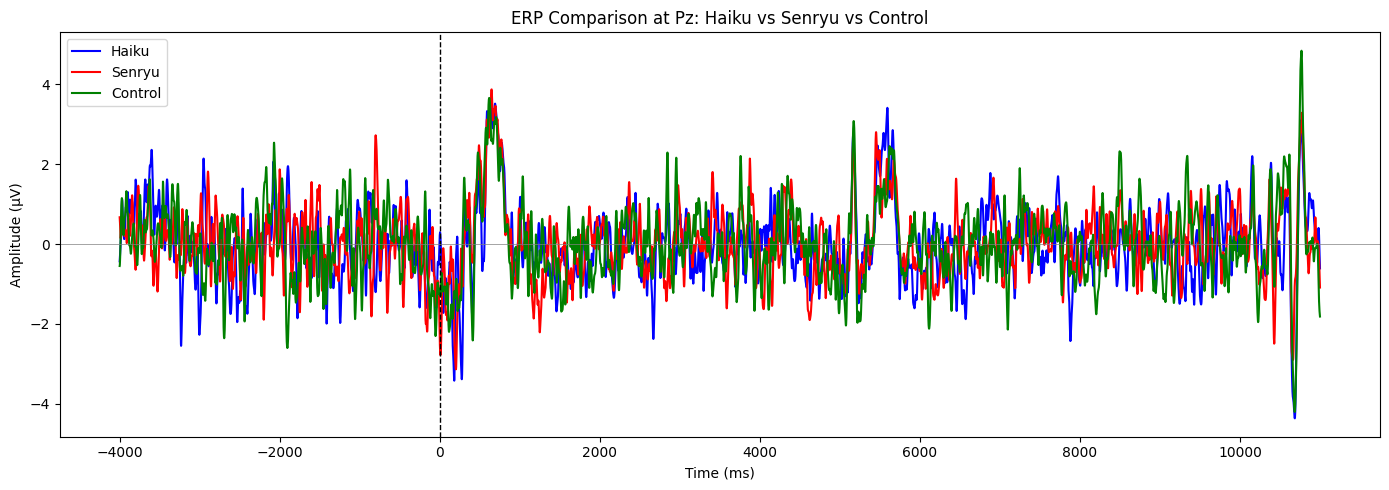

Saved!


In [10]:
import matplotlib.pyplot as plt
import numpy as np


pz_idx = epochs_haiku.ch_names.index('Pz')


haiku_erp = epochs_haiku.average().data[pz_idx] * 1e6
senryu_erp = epochs_senryu.average().data[pz_idx] * 1e6
control_erp = epochs_control.average().data[pz_idx] * 1e6


times = epochs_haiku.times * 1000


fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(times, haiku_erp, color='blue', label='Haiku', linewidth=1.5)
ax.plot(times, senryu_erp, color='red', label='Senryu', linewidth=1.5)
ax.plot(times, control_erp, color='green', label='Control', linewidth=1.5)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('ERP Comparison at Pz: Haiku vs Senryu vs Control')
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEG_Study/ERP_Pz_comparison.png', dpi=150)
plt.show()
print("Saved!")

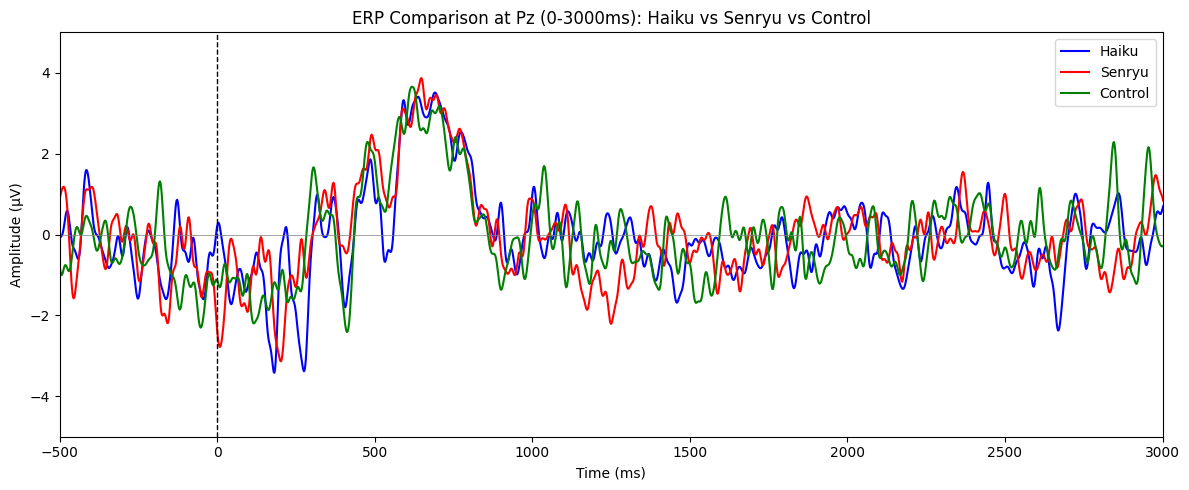

In [11]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(times, haiku_erp, color='blue', label='Haiku', linewidth=1.5)
ax.plot(times, senryu_erp, color='red', label='Senryu', linewidth=1.5)
ax.plot(times, control_erp, color='green', label='Control', linewidth=1.5)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlim(-500, 3000)
ax.set_ylim(-5, 5)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('ERP Comparison at Pz (0-3000ms): Haiku vs Senryu vs Control')
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEG_Study/ERP_Pz_zoom.png', dpi=150)
plt.show()

In [12]:
def preprocess_subject(subject_id):
    """
    subject_id: 예) '001', '002', '003'
    """
    print(f"\n{'='*50}")
    print(f"Processing sub-{subject_id}...")
    print(f"{'='*50}")


    import os
    os.system(f'aws s3 sync --no-sign-request s3://openneuro.org/ds006648/sub-{subject_id} /content/ds006648/sub-{subject_id}')

    set_file = f'/content/ds006648/sub-{subject_id}/eeg/sub-{subject_id}_task-readpoetry_eeg.set'
    if not os.path.exists(set_file):
        print(f"sub-{subject_id}: .set file not found, skipping!")
        return None


    raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)


    exg_channels = [ch for ch in ['EXG1','EXG2','EXG3','EXG4','EXG5','EXG6','EXG7','EXG8'] if ch in raw.ch_names]
    raw.drop_channels(exg_channels)
    montage = mne.channels.make_standard_montage('biosemi64')
    raw.set_montage(montage, on_missing='warn', verbose=False)
    raw.load_data(verbose=False)
    raw.filter(l_freq=1.0, h_freq=40.0, verbose=False)
    raw.set_eeg_reference('average', projection=False, verbose=False)


    raw_short = raw.copy().crop(tmax=min(3000, raw.times[-1]))
    ica = ICA(n_components=63, method='picard', random_state=42, verbose=False)
    ica.fit(raw_short, verbose=False)


    from mne_icalabel import label_components
    ic_labels = label_components(raw_short, ica, method='iclabel')
    labels = ic_labels['labels']
    proba = ic_labels['y_pred_proba']
    exclude = [i for i, label in enumerate(labels)
               if label not in ['brain', 'other']
               and proba[i].max() > 0.9]
    print(f"sub-{subject_id}: Excluding {len(exclude)} components: {exclude}")
    ica.exclude = exclude
    ica.apply(raw, verbose=False)


    events, event_id = mne.events_from_annotations(raw, verbose=False)
    epochs = mne.Epochs(raw, events, event_id={'stimulus': 2},
                        tmin=-4.0, tmax=11.0, baseline=(-4.0, 0),
                        preload=True, verbose=False)
    print(f"sub-{subject_id}: {len(epochs)} epochs created")


    save_path = '/content/drive/MyDrive/EEG_Study/'
    epochs.save(save_path + f'sub-{subject_id}-epo.fif', overwrite=True)
    print(f"sub-{subject_id}: Saved!")

    return epochs

print("Function defined!")

Function defined!


In [ ]:
import gc  # garbage collector


subjects = ['001', '002', '003', '004', '005',
            '006', '007', '008', '009', '010',
            '011', '012', '013', '014', '015',
            '016', '017', '018']

for sub in subjects:

    epochs = preprocess_subject(sub)


    del epochs
    gc.collect()

    print(f"sub-{sub} done, memory cleared!")


Processing sub-001...


/tmp/ipykernel_9048/3948989167.py:19: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
